# Aula 6 - A Meta - Eliyahu M. Goldratt.ipynb

## Diga-me como me medes e eu te direi como me comportarei

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

In [45]:
# 1. Carga dos dados (Heart Disease Dataset - ID 45547 no OpenML/Kaggle)
data = fetch_openml(data_id=45547, as_frame=True, parser='pandas')
data

{'data':          age gender  height  weight  ap_hi  ap_lo cholesterol gluc smoke alco  \
 0      18393      2     168    62.0  110.0   80.0           1    1     0    0   
 1      20228      1     156    85.0  140.0   90.0           3    1     0    0   
 2      18857      1     165    64.0  130.0   70.0           3    1     0    0   
 3      17623      2     169    82.0  150.0  100.0           1    1     0    0   
 4      17474      1     156    56.0  100.0   60.0           1    1     0    0   
 ...      ...    ...     ...     ...    ...    ...         ...  ...   ...  ...   
 69995  19240      2     168    76.0  120.0   80.0           1    1     1    0   
 69996  22601      1     158   126.0  140.0   90.0           2    2     0    0   
 69997  19066      2     183   105.0  180.0   90.0           3    1     0    1   
 69998  22431      1     163    72.0  135.0   80.0           1    2     0    0   
 69999  20540      1     170    72.0  120.0   80.0           2    1     0    0   
 
      

In [50]:
from IPython.display import display, Markdown
display(Markdown(data['DESCR']))

## Data description

There are 3 types of input features:

* Objective: factual information;
* Examination: results of medical examination;
* Subjective: information given by the patient.

Features:

1. Age | Objective Feature | age | int (days)
2. Height | Objective Feature | height | int (cm) |
3. Weight | Objective Feature | weight | float (kg) |
4. Gender | Objective Feature | gender | categorical code |
5. Systolic blood pressure | Examination Feature | ap_hi | int |
6. Diastolic blood pressure | Examination Feature | ap_lo | int |
7. Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |
8. Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |
9. Smoking | Subjective Feature | smoke | binary |
10. Alcohol intake | Subjective Feature | alco | binary |
11. Physical activity | Subjective Feature | active | binary |
12. Presence or absence of cardiovascular disease | Target Variable | cardio | binary |

All of the dataset values were collected at the moment of medical examination.

**Notes by Uploader to OpenML**

* Gender: 1 - women, 2 - men
* There is no information available on Kaggle where this data was collected.

Downloaded from openml.org.

In [52]:
df = pd.DataFrame(data.frame)

Resultado da Classificação
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6988
           1       1.00      1.00      1.00      7012

    accuracy                           1.00     14000
   macro avg       1.00      1.00      1.00     14000
weighted avg       1.00      1.00      1.00     14000



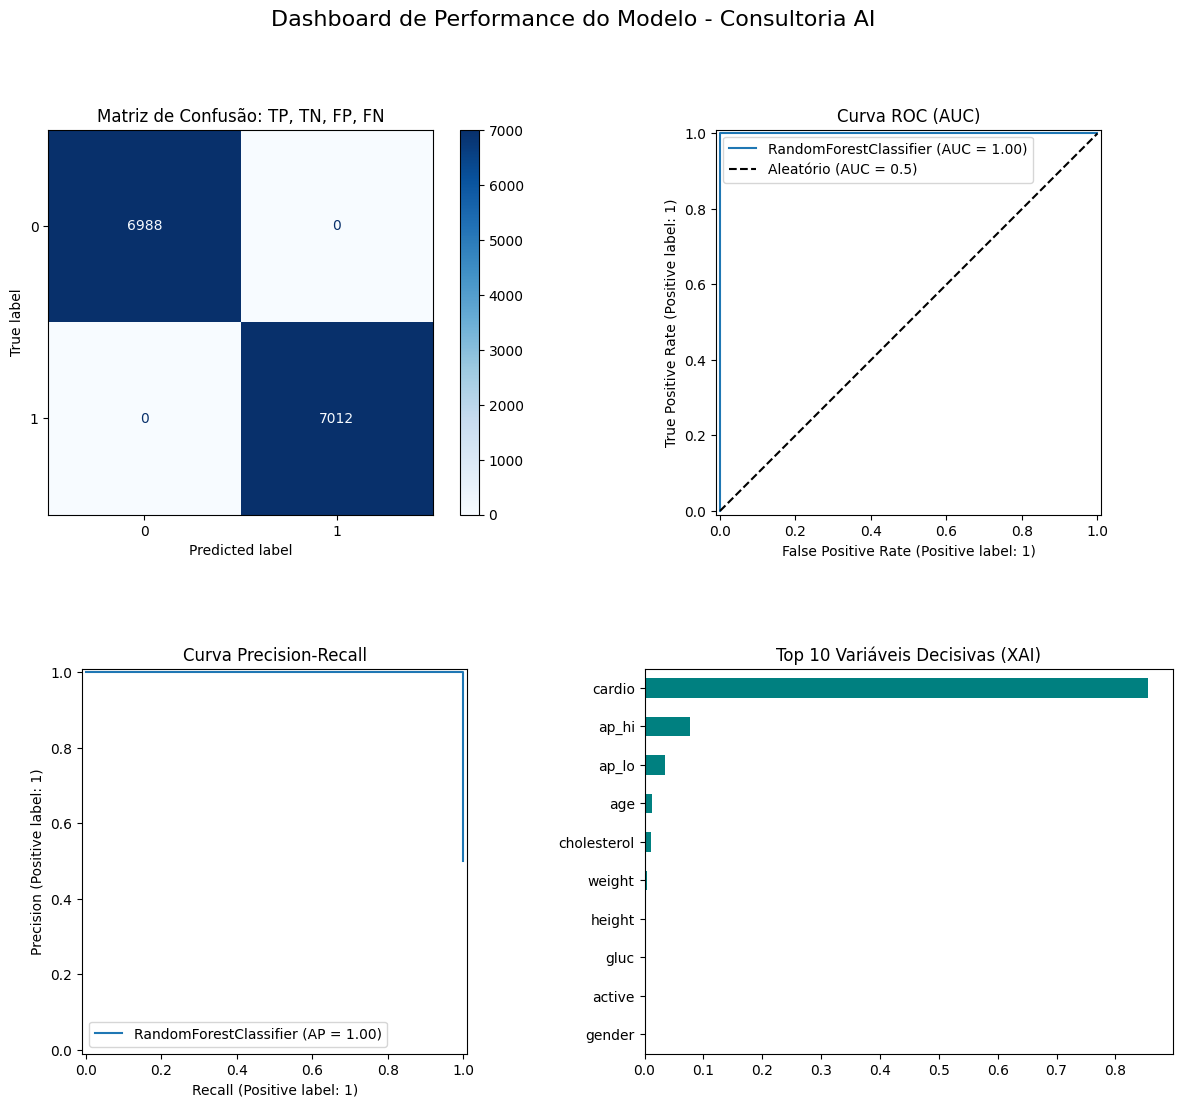

In [54]:
# 2. Pré-processamento rápido
X = df.copy()
y = data.target.astype(int) # Garantindo que o alvo seja binário (0 ou 1)

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização: Essencial para muitos algoritmos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Treinamento do Modelo (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

print("Resultado da Classificação")
print(classification_report(y_test, model.predict(X_test_scaled)))

# 4. Visualização das Métricas Graficamente
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4)

# A) Matriz de Confusão: O 'Raio-X' das previsões
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test,
                                      cmap='Blues', ax=ax1)
ax1.set_title("Matriz de Confusão: TP, TN, FP, FN")

# B) Curva ROC: Equilíbrio entre Sensibilidade e Especificidade
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], "k--", label="Aleatório (AUC = 0.5)")
ax2.set_title("Curva ROC (AUC)")
ax2.legend()

# C) Curva Precision-Recall: Vital para classes desbalanceadas
PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax3)
ax3.set_title("Curva Precision-Recall")

# D) Feature Importance: O que realmente importa para o modelo?
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', color='teal', ax=ax4)
ax4.set_title("Top 10 Variáveis Decisivas (XAI)")

plt.suptitle("Dashboard de Performance do Modelo - Consultoria AI", fontsize=16)
plt.show()

In [55]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110.0,80.0,1,1,0,0,1,0
1,20228,1,156,85.0,140.0,90.0,3,1,0,0,1,1
2,18857,1,165,64.0,130.0,70.0,3,1,0,0,0,1
3,17623,2,169,82.0,150.0,100.0,1,1,0,0,1,1
4,17474,1,156,56.0,100.0,60.0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120.0,80.0,1,1,1,0,1,0
69996,22601,1,158,126.0,140.0,90.0,2,2,0,0,1,1
69997,19066,2,183,105.0,180.0,90.0,3,1,0,1,0,1
69998,22431,1,163,72.0,135.0,80.0,1,2,0,0,0,1


## Bônus - Data Leakage

In [58]:
df.corr()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159
gender,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109
height,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821
weight,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660
ap_hi,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475
ap_lo,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719
cholesterol,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147
gluc,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307
smoke,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486
alco,-0.029723,0.170966,0.094419,0.067113,0.001408,0.010601,0.035760,0.011246,0.340094,1.000000,0.025476,-0.007330


Resultado da Classificação
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      6988
           1       0.72      0.70      0.71      7012

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000



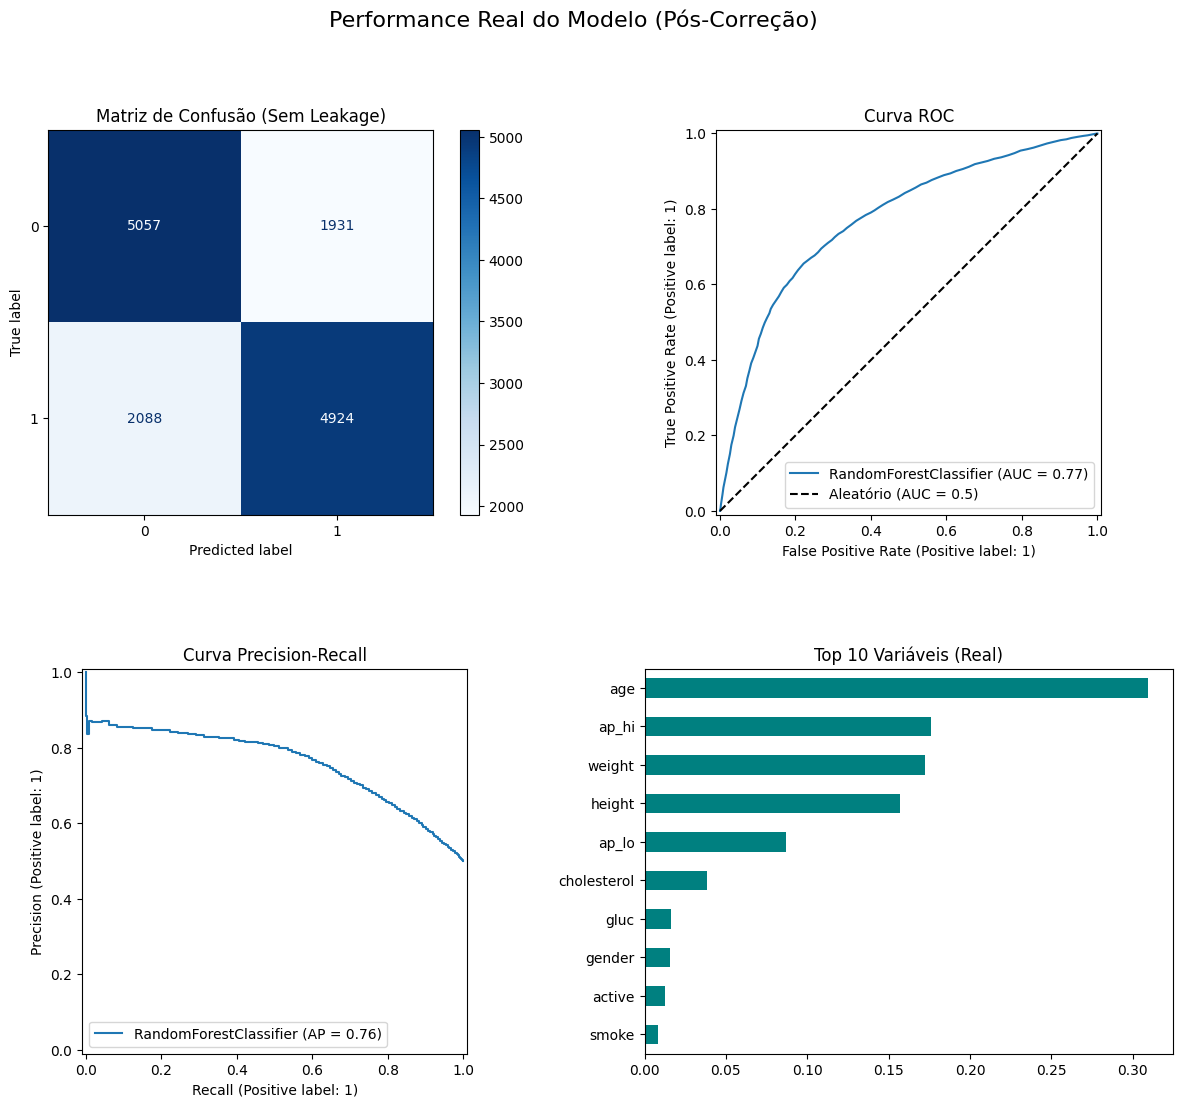

In [59]:
# Solução do Data Leakage: Remover a variável alvo ('cardio') das features
# Antes, X incluía 'cardio', permitindo que o modelo visse a resposta.

X = df.drop(columns=['cardio']) # Correção: Features sem a resposta
y = data.target.astype(int)

# 1. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Normalização (Fit apenas no treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Treinamento (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

print("Resultado da Classificação")
print(classification_report(y_test, model.predict(X_test_scaled)))

# 4. Visualização Corrigida
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4)

# Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, cmap='Blues', ax=ax1)
ax1.set_title("Matriz de Confusão (Sem Leakage)")

# Curva ROC
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], "k--", label="Aleatório (AUC = 0.5)")
ax2.set_title("Curva ROC")
ax2.legend()

# Precision-Recall
PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax3)
ax3.set_title("Curva Precision-Recall")

# Feature Importance (Agora real)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', color='teal', ax=ax4)
ax4.set_title("Top 10 Variáveis (Real)")

plt.suptitle("Performance Real do Modelo (Pós-Correção)", fontsize=16)
plt.show()